# Analyse der Page Revisions

## Technische Definitionen
### Import der benötigten Module

In [34]:
from tqdm import tqdm
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt

### Variablen

Diese Variablen werden benötigt für einen aussagekräftigen Request-Header, den die MediaWiki-Schnittstelle verlangt.
Die Werte können beliebig gewählt werden.

In [24]:
appName = "appName"
email = "b@a.com"
DB_NAME = "test.db"

### Funktionen

In [25]:
def store_revision(conn, rev, obj):
    '''Schreibt die Revisionen zu einem Objekt in die Datenbank.'''
    c = conn.cursor()

    c.execute("""
        INSERT OR REPLACE INTO revisions
        (object, revid, parentid, user, anon, timestamp, size, comment)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        obj,
        rev["revid"],
        rev["parentid"],
        rev.get("user"),
        rev.get("anon"),
        rev["timestamp"],
        rev.get("size"),
        rev.get("comment")
    ))

    # Insert tags
    tags = rev.get("tags", [])
    for t in tags:
        c.execute("""
            INSERT INTO revision_tags (revid, tag)
            VALUES (?, ?)
        """, (rev["revid"], t))

    conn.commit()


def get_wikidata_revisions(qid, limit = 500):
    """
    Ruft alle Revisionen eine Wikidata-Objekt ab.
    """
    url = "https://www.wikidata.org/w/api.php"

    headers = {
        'User-Agent': f'{appName} ({email})'
    }

    params = {
        "action": "query",
        "prop": "revisions",
        "titles": qid,
        "rvprop": "ids|timestamp|user|size|tags|comment",
        "rvlimit": limit,   # max for bots; 50 for normal accounts
        "format": "json"
    }

    revisions = []
    rvcontinue = None

    while True:
        if rvcontinue:
            params["rvcontinue"] = rvcontinue

        r = requests.get(url, params=params, headers=headers)
        r.raise_for_status()
        data = r.json()

        page = next(iter(data["query"]["pages"].values()))
        batch = page.get("revisions", [])
        revisions.extend(batch)

        # Check if there's more
        if "continue" in data:
            rvcontinue = data["continue"]["rvcontinue"]
        else:
            break

    return revisions

### Einrichten der Datenbank

In [26]:
conn = sqlite3.connect(DB_NAME)
c = conn.cursor()
c.execute("""CREATE TABLE IF NOT EXISTS revisions (
    object TEXT,
    revid INTEGER PRIMARY KEY,
    parentid INTEGER,
    user TEXT,
    anon TEXT,
    timestamp TEXT,
    size INTEGER,
    comment TEXT
);""")
c.execute("""CREATE TABLE IF NOT EXISTS revision_tags (
    revid INTEGER,
    tag TEXT,
    FOREIGN KEY(revid) REFERENCES revisions(revid)
);""")

conn.commit()

## Datenabruf aus Wikidata (über [QLever-Endpunkt](https://qlever.dev/wikidata))

In [27]:
qleverEndpoint = "https://qlever.dev/api/wikidata"
headers = {
    "Accept" : "application/sparql-results+json",
    "Content-type" : "application/sparql-query"
}
query = """
PREFIX wd: <http://www.wikidata.org/entity/>
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX wikibase: <http://wikiba.se/ontology#>
SELECT DISTINCT ?sosaffil WHERE {
 ?sosaffil ?x wd:Q1376560 ; wikibase:sitelinks [] . # hack to get Items only, cf. https://www.mediawiki.org/wiki/Wikibase/Indexing/RDF_Dump_Format#WDQS_data_differences
} LIMIT 5
"""

response = requests.post(qleverEndpoint, headers = headers, data = query)
data = response.json()

### Abruf der Edit-History

**Zu Beachten**: Es bietet sich an, zu Testzwecken Revisions nur für eine kleine Zahl von Items abzurufen.

In [28]:
errors_qid = list()
with conn:
    for row in tqdm(data['results']['bindings']):
        obj = row['sosaffil']['value'].rpartition('/')[2]
        try:
            revisions = get_wikidata_revisions(obj)
            for rev in revisions:
                store_revision(conn, rev, obj)
        except Exception as e:
            print(e, qid)
            errors_qid.append(qid)

100%|█████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.84it/s]


## Analyse und Visualisierung

In [22]:
### Neu erstellte Items

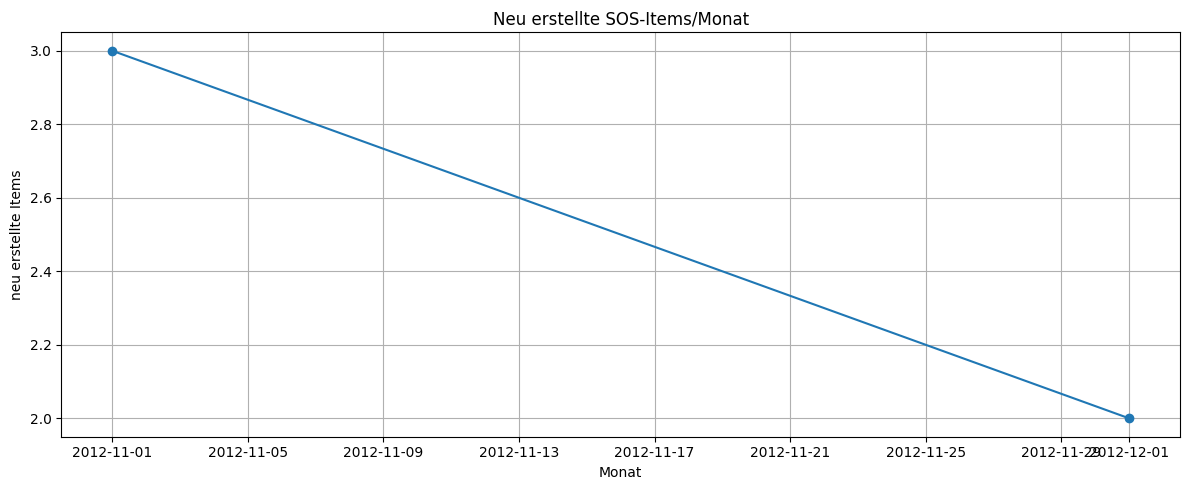

In [29]:
# Connect to database
conn = sqlite3.connect(DB_NAME)

# Query monthly counts
df = pd.read_sql_query("""
SELECT
    strftime('%Y-%m', firstEdit) AS month,
    COUNT(*) AS countObjects
FROM (
  SELECT
    object,
    MIN(timestamp) AS firstEdit
  FROM revisions
  GROUP BY object
)
GROUP BY month
ORDER BY month;
""", conn)

conn.close()

# Convert to datetime index
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)

# Create a complete monthly index (from min to max)
full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='MS'  # Month Start frequency
)

# Reindex and fill missing months with 0
df = df.reindex(full_index, fill_value=0)

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['countObjects'], marker='o')
plt.title("Neu erstellte SOS-Items/Monat")
plt.xlabel("Monat")
plt.ylabel("neu erstellte Items")
plt.grid(True)
plt.tight_layout()
plt.show()

### Monatliche Edits

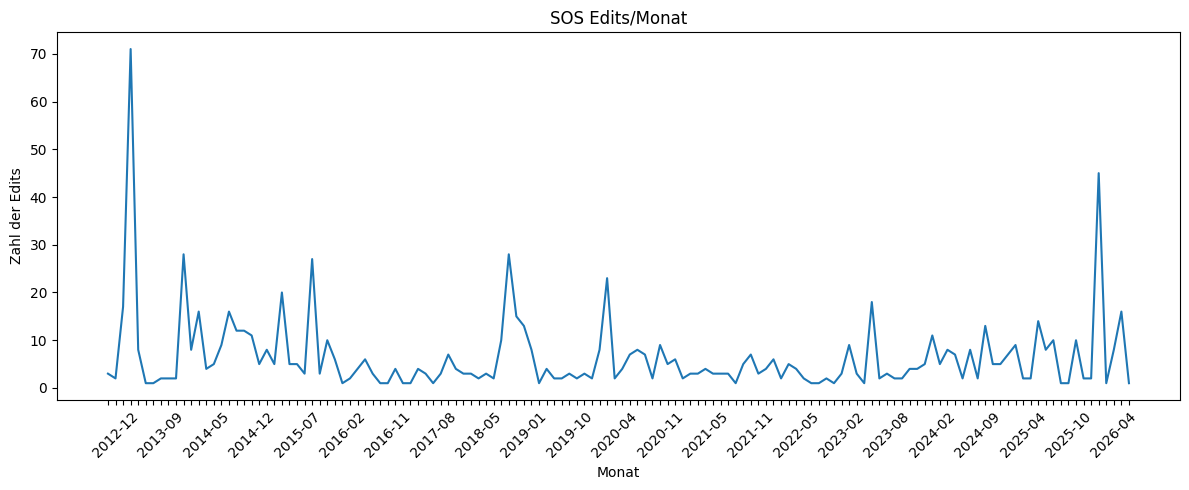

In [30]:
# Connect to database
conn = sqlite3.connect(DB_NAME)

# Query monthly counts
df = pd.read_sql_query("""
SELECT
    strftime('%Y-%m', timestamp) AS month,
    COUNT(revid) AS revCount
FROM (
  SELECT
    revid,
    timestamp
  FROM revisions
)
GROUP BY month
ORDER BY month;
""", conn)

conn.close()

n = 6  # Show label every 3rd month

plt.figure(figsize=(12,5))
plt.plot(df["month"], df['revCount'])
plt.title("SOS Edits/Monat")
plt.xlabel("Monat")
plt.ylabel("Zahl der Edits")
plt.grid(False)
ax = plt.gca() # Get current axis
ax.set_xticks(range(len(df))) # Force a tick mark for EVERY month
ax.set_xticklabels([x if i % n == 0 else '' for i, x in enumerate(df['month'], start = -1)], rotation=45)

plt.tight_layout()
plt.show()

### Manuelle Edits pro Monat

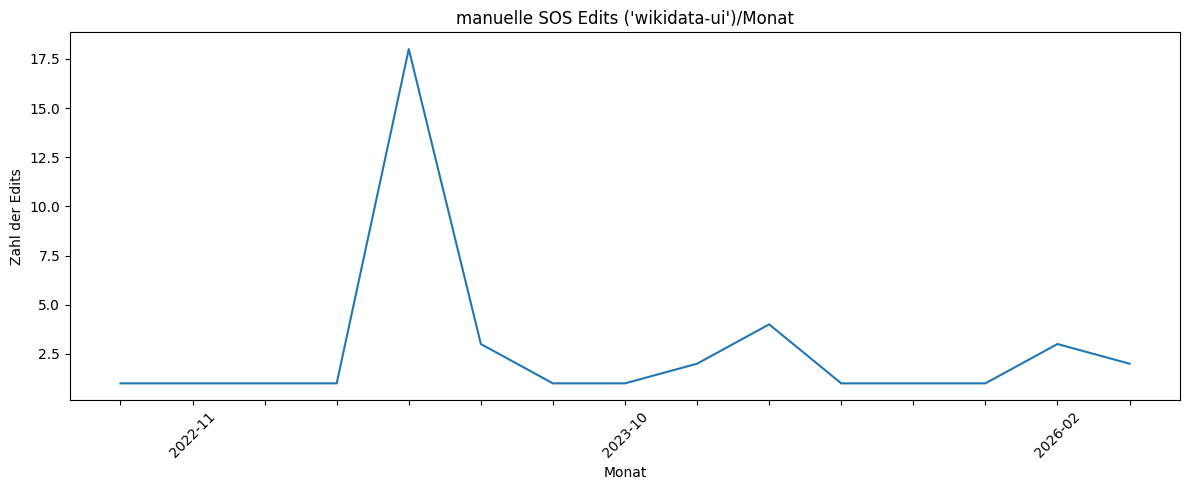

In [31]:
# Connect to database
conn = sqlite3.connect(DB_NAME)

# Query monthly counts
df = pd.read_sql_query("""
SELECT
    strftime('%Y-%m', timestamp) AS month,
    COUNT(revid) AS revCount
FROM (
  SELECT
    r.revid,
    timestamp
  FROM revisions r
  JOIN revision_tags AS t ON t.revid = r.revid
  WHERE t.tag = "wikidata-ui"
)
GROUP BY month
ORDER BY month;
""", conn)

conn.close()

n = 6  # Show label every 3rd month

plt.figure(figsize=(12,5))
plt.plot(df["month"], df['revCount'])
plt.title("manuelle SOS Edits ('wikidata-ui')/Monat")
plt.xlabel("Monat")
plt.ylabel("Zahl der Edits")
plt.grid(False)
ax = plt.gca() # Get current axis
ax.set_xticks(range(len(df))) # Force a tick mark for EVERY month
ax.set_xticklabels([x if i % n == 0 else '' for i, x in enumerate(df['month'], start = -1)], rotation=45)
plt.tight_layout()
plt.show()

### Zahl distinkte Beitragender pro Monat

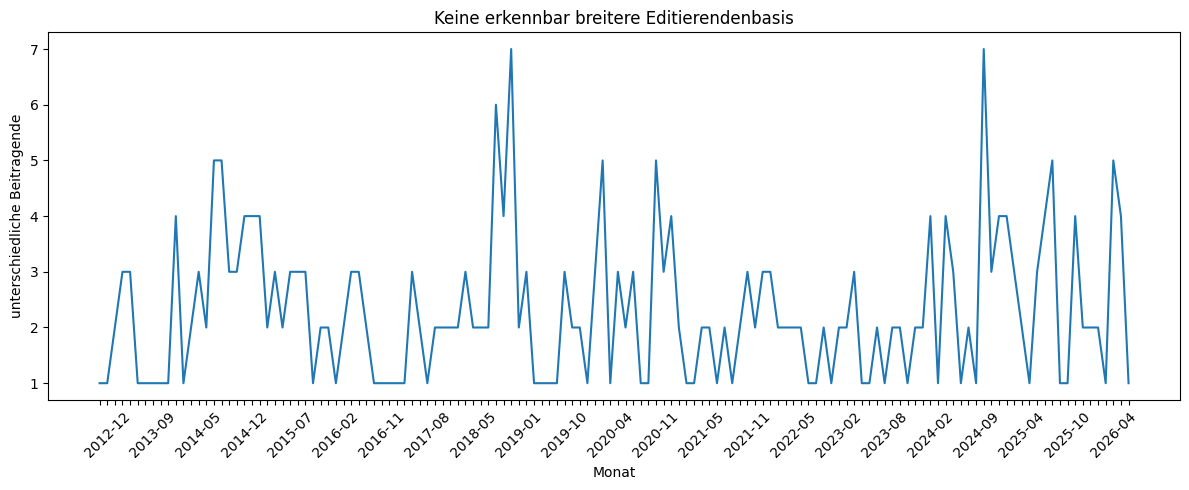

In [32]:
# Connect to database
conn = sqlite3.connect(DB_NAME)

# Query monthly counts
df = pd.read_sql_query("""
SELECT
    strftime('%Y-%m', timestamp) AS month,
    COUNT (DISTINCT user) AS distinctUsers
FROM (
  SELECT
	user,
    timestamp
  FROM revisions
)
GROUP BY month
ORDER BY month;
""", conn)

conn.close()

n = 6  # Show label every 3rd month

plt.figure(figsize=(12,5))
plt.plot(df["month"], df['distinctUsers'])
plt.title("Keine erkennbar breitere Editierendenbasis")
plt.xlabel("Monat")
plt.ylabel("unterschiedliche Beitragende")
plt.grid(False)
ax = plt.gca() # Get current axis
ax.set_xticks(range(len(df))) # Force a tick mark for EVERY month
ax.set_xticklabels([x if i % n == 0 else '' for i, x in enumerate(df['month'], start = -1)], rotation=45)
plt.tight_layout()
plt.show()